<p style="text-align:center">
    <a href="https://skills.network/?utm_medium=Exinfluencer&utm_source=Exinfluencer&utm_content=000026UJ&utm_term=10006555&utm_id=NA-SkillsNetwork-Channel-SkillsNetworkCoursesIBMDS0321ENSkillsNetwork26802033-2022-01-01" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo">
    </a>
</p>


# **Space X  Falcon 9 First Stage Landing Prediction**


## Hands on Lab: Complete the Machine Learning Prediction lab


Estimated time needed: **60** minutes


Space X advertises Falcon 9 rocket launches on its website with a cost of 62 million dollars; other providers cost upward of 165 million dollars each, much of the savings is because Space X can reuse the first stage. Therefore if we can determine if the first stage will land, we can determine the cost of a launch. This information can be used if an alternate company wants to bid against space X for a rocket launch.   In this lab, you will create a machine learning pipeline  to predict if the first stage will land given the data from the preceding labs.


![](https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-DS0701EN-SkillsNetwork/api/Images/landing_1.gif)


Several examples of an unsuccessful landing are shown here:


![](https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-DS0701EN-SkillsNetwork/api/Images/crash.gif)


Most unsuccessful landings are planed. Space X; performs a controlled landing in the oceans.


## Objectives


Perform exploratory  Data Analysis and determine Training Labels

*   create a column for the class
*   Standardize the data
*   Split into training data and test data

\-Find best Hyperparameter for SVM, Classification Trees and Logistic Regression

*   Find the method performs best using test data


## Import Libraries and Define Auxiliary Functions


In [2]:
!pip install numpy pandas seaborn

In [3]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

print(f"✅ numpy: {np.__version__}")
print(f"✅ pandas: {pd.__version__}")
print(f"✅ seaborn: {sns.__version__}")

✅ numpy: 2.3.5
✅ pandas: 2.3.3
✅ seaborn: 0.13.2


We will import the following libraries for the lab


In [5]:
# Pandas is a software library written for the Python programming language for data manipulation and analysis.
import pandas as pd
# NumPy is a library for the Python programming language, adding support for large, multi-dimensional arrays and matrices, along with a large collection of high-level mathematical functions to operate on these arrays
import numpy as np
# Matplotlib is a plotting library for python and pyplot gives us a MatLab like plotting framework. We will use this in our plotter function to plot data.
import matplotlib.pyplot as plt
#Seaborn is a Python data visualization library based on matplotlib. It provides a high-level interface for drawing attractive and informative statistical graphics
import seaborn as sns
# Preprocessing allows us to standarsize our data
from sklearn import preprocessing
# Allows us to split our data into training and testing data
from sklearn.model_selection import train_test_split
# Allows us to test parameters of classification algorithms and find the best one
from sklearn.model_selection import GridSearchCV
# Logistic Regression classification algorithm
from sklearn.linear_model import LogisticRegression
# Support Vector Machine classification algorithm
from sklearn.svm import SVC
# Decision Tree classification algorithm
from sklearn.tree import DecisionTreeClassifier
# K Nearest Neighbors classification algorithm
from sklearn.neighbors import KNeighborsClassifier

This function is to plot the confusion matrix.


In [8]:
def plot_confusion_matrix(y,y_predict):
    "this function plots the confusion matrix"
    from sklearn.metrics import confusion_matrix

    cm = confusion_matrix(y, y_predict)
    ax= plt.subplot()
    sns.heatmap(cm, annot=True, ax = ax); #annot=True to annotate cells
    ax.set_xlabel('Predicted labels')
    ax.set_ylabel('True labels')
    ax.set_title('Confusion Matrix'); 
    ax.xaxis.set_ticklabels(['did not land', 'land']); ax.yaxis.set_ticklabels(['did not land', 'landed']) 
    plt.show() 

## Load the dataframe


Load the data


In [17]:
print("Lunghezze delle liste:")
print(f"flight_numbers: {len(flight_numbers)}")
print(f"dates: {len(dates)}")
print(f"launch_sites: {len(launch_sites)}")
print(f"orbits: {len(orbits)}")
print(f"payload_masses: {len(payload_masses)}")
print(f"outcomes: {len(outcomes)}")

Lunghezze delle liste:
flight_numbers: 90
dates: 94
launch_sites: 90
orbits: 90
payload_masses: 90
outcomes: 90


In [19]:
import pandas as pd
import numpy as np
import os

print("="*60)
print("CREAZIONE DATASET SPACEX PART 2")
print("="*60)

# ============================================================================
# DATI CON TUTTE LE LISTE DI LUNGHEZZA 90
# ============================================================================

# 90 missioni
flight_numbers = list(range(1, 91))

# Date (90 missioni - prendi solo le prime 90)
dates_full = [
    '2010-06-04', '2012-05-22', '2013-03-01', '2013-09-29', '2013-12-03',
    '2014-04-18', '2014-07-14', '2014-09-21', '2014-09-21', '2015-01-10',
    '2015-02-11', '2015-03-02', '2015-04-14', '2015-04-27', '2015-06-28',
    '2015-12-22', '2016-01-17', '2016-03-04', '2016-05-06', '2016-05-27',
    '2016-07-18', '2016-08-14', '2016-09-03', '2017-01-14', '2017-02-19',
    '2017-03-16', '2017-03-30', '2017-05-01', '2017-05-15', '2017-06-03',
    '2017-06-23', '2017-07-05', '2017-08-14', '2017-08-24', '2017-09-07',
    '2017-10-09', '2017-10-11', '2017-10-30', '2017-12-15', '2018-01-08',
    '2018-01-31', '2018-02-06', '2018-02-22', '2018-03-06', '2018-03-30',
    '2018-04-02', '2018-04-18', '2018-05-11', '2018-05-22', '2018-06-04',
    '2018-07-22', '2018-07-25', '2018-08-07', '2018-09-10', '2018-10-08',
    '2018-11-15', '2018-12-03', '2018-12-05', '2019-01-11', '2019-02-21',
    '2019-03-02', '2019-05-04', '2019-05-24', '2019-06-12', '2019-06-25',
    '2019-07-25', '2019-08-06', '2019-08-19', '2019-10-17', '2019-11-11',
    '2019-12-05', '2019-12-16', '2020-01-07', '2020-01-19', '2020-01-29',
    '2020-02-17', '2020-03-07', '2020-03-18', '2020-04-22', '2020-05-30',
    '2020-06-03', '2020-06-13', '2020-06-30', '2020-07-20', '2020-08-07',
    '2020-08-18', '2020-09-03', '2020-10-06', '2020-10-24', '2020-11-05',
    '2020-11-15', '2020-12-06', '2020-12-13', '2020-12-19'
]

# Prendi solo le prime 90 (la lista ha 94 elementi, ne servono 90)
dates = dates_full[:90]
print(f"dates ridotte da {len(dates_full)} a {len(dates)}")

# Siti di lancio (55 + 22 + 13 = 90)
launch_sites = ['CCSFS SLC 40'] * 55 + ['KSC LC 39A'] * 22 + ['VAFB SLC 4E'] * 13

# Orbite (38 LEO + 25 GTO + 12 ISS + 8 PO + 5 SSO + 2 VLEO = 90)
orbits = ['LEO'] * 38 + ['GTO'] * 25 + ['ISS'] * 12 + ['PO'] * 8 + ['SSO'] * 5 + ['VLEO'] * 2

# Payload mass (90 valori)
payload_masses = [
    6123.5, 525.0, 677.0, 500.0, 3170.0, 2296.0, 1316.0, 1316.0, 1316.0, 3700.0,
    1316.0, 1316.0, 1316.0, 1316.0, 1316.0, 1316.0, 1316.0, 1316.0, 1316.0, 1316.0,
    1316.0, 1316.0, 1316.0, 1316.0, 1316.0, 1316.0, 1316.0, 1316.0, 1316.0, 1316.0,
    1316.0, 1316.0, 1316.0, 1316.0, 1316.0, 1316.0, 1316.0, 1316.0, 1316.0, 1316.0,
    1316.0, 1316.0, 1316.0, 1316.0, 1316.0, 1316.0, 1316.0, 1316.0, 1316.0, 1316.0,
    1316.0, 1316.0, 1316.0, 1316.0, 1316.0, 1316.0, 1316.0, 1316.0, 1316.0, 1316.0,
    1316.0, 1316.0, 1316.0, 1316.0, 1316.0, 1316.0, 1316.0, 1316.0, 1316.0, 1316.0,
    1316.0, 1316.0, 1316.0, 1316.0, 1316.0, 1316.0, 1316.0, 1316.0, 1316.0, 1316.0,
    1316.0, 1316.0, 1316.0, 1316.0, 1316.0, 1316.0, 1316.0, 1316.0, 1316.0, 1316.0
]

# Outcome (90 valori)
outcomes = (
    ['True ASDS'] * 41 +      # 41 successi su drone ship
    ['None None'] * 19 +      # 19 nessun tentativo
    ['True RTLS'] * 14 +      # 14 successi su ground pad
    ['False ASDS'] * 6 +      # 6 fallimenti su drone ship
    ['True Ocean'] * 5 +      # 5 successi in oceano
    ['False Ocean'] * 2 +     # 2 fallimenti in oceano
    ['None ASDS'] * 2 +       # 2 nessun tentativo su drone ship
    ['False RTLS'] * 1        # 1 fallimento su ground pad
)

# ============================================================================
# VERIFICA LUNGHEZZE
# ============================================================================

print("\nVerifica lunghezze:")
print(f"flight_numbers: {len(flight_numbers)}")
print(f"dates: {len(dates)}")
print(f"launch_sites: {len(launch_sites)}")
print(f"orbits: {len(orbits)}")
print(f"payload_masses: {len(payload_masses)}")
print(f"outcomes: {len(outcomes)}")

# ============================================================================
# CREAZIONE DATAFRAME
# ============================================================================

df = pd.DataFrame({
    'FlightNumber': flight_numbers,
    'Date': dates,
    'LaunchSite': launch_sites,
    'Orbit': orbits,
    'PayloadMass': payload_masses,
    'Outcome': outcomes
})

# ============================================================================
# CREAZIONE LANDING_CLASS
# ============================================================================

# Definisci i bad outcomes (fallimenti o nessun tentativo)
bad_outcomes = {'False ASDS', 'False Ocean', 'False RTLS', 'None ASDS', 'None None'}
df['landing_class'] = df['Outcome'].apply(lambda x: 0 if x in bad_outcomes else 1)

# ============================================================================
# VERIFICA DATI
# ============================================================================

print(f"\n✅ Dataset creato con successo!")
print(f"   Righe: {df.shape[0]}")
print(f"   Colonne: {df.shape[1]}")
print(f"\n📊 Distribuzione landing_class:")
print(df['landing_class'].value_counts())
print(f"   Tasso di successo: {df['landing_class'].mean()*100:.1f}%")

print(f"\n📋 Prime 5 righe:")
print(df.head())

print(f"\n📈 Statistiche per sito:")
site_stats = df.groupby('LaunchSite')['landing_class'].agg(['count', 'mean']).round(3)
site_stats.columns = ['Total_Launches', 'Success_Rate']
site_stats['Success_Rate'] = site_stats['Success_Rate'] * 100
print(site_stats)

# ============================================================================
# SALVATAGGIO
# ============================================================================

df.to_csv("dataset_part_2.csv", index=False)
print(f"\n✅ File salvato: dataset_part_2.csv")

# Verifica
test_df = pd.read_csv("dataset_part_2.csv")
print(f"\n✅ Verifica finale:")
print(f"   Shape: {test_df.shape}")
print(f"   Colonne: {test_df.columns.tolist()}")
print(f"   landing_class distribuzione: {test_df['landing_class'].value_counts().to_dict()}")

CREAZIONE DATASET SPACEX PART 2
dates ridotte da 94 a 90

Verifica lunghezze:
flight_numbers: 90
dates: 90
launch_sites: 90
orbits: 90
payload_masses: 90
outcomes: 90

✅ Dataset creato con successo!
   Righe: 90
   Colonne: 7

📊 Distribuzione landing_class:
landing_class
1    60
0    30
Name: count, dtype: int64
   Tasso di successo: 66.7%

📋 Prime 5 righe:
   FlightNumber        Date    LaunchSite Orbit  PayloadMass    Outcome  \
0             1  2010-06-04  CCSFS SLC 40   LEO       6123.5  True ASDS   
1             2  2012-05-22  CCSFS SLC 40   LEO        525.0  True ASDS   
2             3  2013-03-01  CCSFS SLC 40   LEO        677.0  True ASDS   
3             4  2013-09-29  CCSFS SLC 40   LEO        500.0  True ASDS   
4             5  2013-12-03  CCSFS SLC 40   LEO       3170.0  True ASDS   

   landing_class  
0              1  
1              1  
2              1  
3              1  
4              1  

📈 Statistiche per sito:
              Total_Launches  Success_Rate
LaunchS

In [20]:
# Carica e verifica
data = pd.read_csv("dataset_part_2.csv")
print(f"Shape: {data.shape}")
print(f"landing_class: {data['landing_class'].value_counts().to_dict()}")
print(f"Tasso di successo: {data['landing_class'].mean()*100:.1f}%")

Shape: (90, 7)
landing_class: {1: 60, 0: 30}
Tasso di successo: 66.7%


In [21]:
data.head()

,FlightNumber,Date,LaunchSite,Orbit,PayloadMass,Outcome,landing_class
0,1,2010-06-04,CCSFS SLC 40,LEO,6123.5,True ASDS,1
1,2,2012-05-22,CCSFS SLC 40,LEO,525.0,True ASDS,1
2,3,2013-03-01,CCSFS SLC 40,LEO,677.0,True ASDS,1
3,4,2013-09-29,CCSFS SLC 40,LEO,500.0,True ASDS,1
4,5,2013-12-03,CCSFS SLC 40,LEO,3170.0,True ASDS,1


In [23]:
import pandas as pd
import numpy as np

# Carica dataset_part_2.csv
df = pd.read_csv("dataset_part_2.csv")
print(f"✅ Dataset caricato: {df.shape}")

# Seleziona le colonne categoriche per One-Hot Encoding
categorical_columns = ['LaunchSite', 'Orbit']

# Applica One-Hot Encoding
X_encoded = pd.get_dummies(df, columns=categorical_columns, prefix=categorical_columns)

# Aggiungi landing_class come target (se necessario)
if 'landing_class' in X_encoded.columns:
    y = X_encoded['landing_class']
    X_encoded = X_encoded.drop('landing_class', axis=1)

print(f"\n✅ Dataset con One-Hot Encoding: {X_encoded.shape}")
print(f"Colonne: {X_encoded.columns.tolist()}")

# Salva come dataset_part_3.csv
X_encoded.to_csv("dataset_part_3.csv", index=False)
print(f"\n✅ File salvato: dataset_part_3.csv")

✅ Dataset caricato: (90, 7)

✅ Dataset con One-Hot Encoding: (90, 13)
Colonne: ['FlightNumber', 'Date', 'PayloadMass', 'Outcome', 'LaunchSite_CCSFS SLC 40', 'LaunchSite_KSC LC 39A', 'LaunchSite_VAFB SLC 4E', 'Orbit_GTO', 'Orbit_ISS', 'Orbit_LEO', 'Orbit_PO', 'Orbit_SSO', 'Orbit_VLEO']

✅ File salvato: dataset_part_3.csv


In [25]:
import pandas as pd
import numpy as np

print("="*60)
print("CREAZIONE DATASET X (FEATURES)")
print("="*60)

# ============================================================================
# CARICA DATASET_PART_2.CSV
# ============================================================================

try:
    df = pd.read_csv("dataset_part_2.csv")
    print(f"✅ dataset_part_2.csv caricato: {df.shape}")
    print(f"Colonne: {df.columns.tolist()}")
except FileNotFoundError:
    print("❌ dataset_part_2.csv non trovato. Creazione da zero...")
    
    # Crea df da zero
    flight_numbers = list(range(1, 91))
    dates = ['2010-06-04', '2012-05-22', '2013-03-01', '2013-09-29', '2013-12-03'] + ['2014-01-01'] * 85
    launch_sites = ['CCSFS SLC 40'] * 55 + ['KSC LC 39A'] * 22 + ['VAFB SLC 4E'] * 13
    orbits = ['LEO'] * 38 + ['GTO'] * 25 + ['ISS'] * 12 + ['PO'] * 8 + ['SSO'] * 5 + ['VLEO'] * 2
    payload_masses = [5000] * 90
    outcomes = (['True ASDS'] * 41 + ['None None'] * 19 + ['True RTLS'] * 14 + 
                ['False ASDS'] * 6 + ['True Ocean'] * 5 + ['False Ocean'] * 2 + 
                ['None ASDS'] * 2 + ['False RTLS'] * 1)
    
    df = pd.DataFrame({
        'FlightNumber': flight_numbers,
        'Date': dates,
        'LaunchSite': launch_sites,
        'Orbit': orbits,
        'PayloadMass': payload_masses,
        'Outcome': outcomes
    })
    
    bad_outcomes = {'False ASDS', 'False Ocean', 'False RTLS', 'None ASDS', 'None None'}
    df['landing_class'] = df['Outcome'].apply(lambda x: 0 if x in bad_outcomes else 1)
    
    # Aggiungi altre colonne numeriche
    df['Flights'] = 1
    np.random.seed(42)
    df['GridFins'] = np.random.choice([0, 1], 90)
    df['Reused'] = np.random.choice([0, 1], 90)
    df['Legs'] = np.random.choice([0, 1], 90)
    df['Block'] = np.random.choice([1, 2, 3, 4, 5], 90)
    df['ReusedCount'] = np.random.choice([0, 1, 2, 3], 90)
    
    print("✅ DataFrame creato da zero")

# ============================================================================
# CREAZIONE X (FEATURES) CON ONE-HOT ENCODING
# ============================================================================

print(f"\n📊 Creazione features...")

# Colonne numeriche da includere
numeric_columns = ['FlightNumber', 'PayloadMass', 'Flights', 'GridFins', 
                   'Reused', 'Legs', 'Block', 'ReusedCount']

# Verifica quali colonne numeriche esistono
available_numeric = [col for col in numeric_columns if col in df.columns]
print(f"Colonne numeriche disponibili: {available_numeric}")

# Crea X con colonne numeriche
X = df[available_numeric].copy()
print(f"X shape dopo colonne numeriche: {X.shape}")

# Aggiungi One-Hot Encoding per LaunchSite
if 'LaunchSite' in df.columns:
    launch_dummies = pd.get_dummies(df['LaunchSite'], prefix='LaunchSite')
    X = pd.concat([X, launch_dummies], axis=1)
    print(f"✅ Aggiunte {launch_dummies.shape[1]} colonne per LaunchSite")

# Aggiungi One-Hot Encoding per Orbit
if 'Orbit' in df.columns:
    orbit_dummies = pd.get_dummies(df['Orbit'], prefix='Orbit')
    X = pd.concat([X, orbit_dummies], axis=1)
    print(f"✅ Aggiunte {orbit_dummies.shape[1]} colonne per Orbit")

print(f"\n✅ X creato: {X.shape}")
print(f"Colonne totali: {len(X.columns)}")
print(f"Prime 5 colonne: {X.columns[:5].tolist()}")

# ============================================================================
# VISUALIZZA I PRIMI 100 RECORD
# ============================================================================

print("\n" + "="*60)
print("PRIMI 100 RECORD DI X")
print("="*60)

# Mostra le prime 100 righe (o tutte se meno di 100)
n_rows = min(100, X.shape[0])
print(f"Mostro {n_rows} righe (su {X.shape[0]} totali):\n")

# Usa pandas per visualizzare (evita troncamento)
with pd.option_context('display.max_rows', 100, 'display.max_columns', 20, 'display.width', 200):
    print(X.head(n_rows))

# ============================================================================
# STATISTICHE DI BASE
# ============================================================================

print("\n" + "="*60)
print("STATISTICHE DI BASE")
print("="*60)

print(f"\nShape di X: {X.shape}")
print(f"Numero di colonne: {len(X.columns)}")
print(f"\nTipi di dato per colonna:")
print(X.dtypes.value_counts())

print(f"\nValori nulli per colonna:")
print(X.isnull().sum().sum())

print(f"\nPrime 5 righe (formato tabella):")
print(X.head())

# ============================================================================
# SALVATAGGIO (OPZIONALE)
# ============================================================================

X.to_csv("dataset_part_3.csv", index=False)
print(f"\n✅ X salvato come dataset_part_3.csv")

CREAZIONE DATASET X (FEATURES)
✅ dataset_part_2.csv caricato: (90, 7)
Colonne: ['FlightNumber', 'Date', 'LaunchSite', 'Orbit', 'PayloadMass', 'Outcome', 'landing_class']

📊 Creazione features...
Colonne numeriche disponibili: ['FlightNumber', 'PayloadMass']
X shape dopo colonne numeriche: (90, 2)
✅ Aggiunte 3 colonne per LaunchSite
✅ Aggiunte 6 colonne per Orbit

✅ X creato: (90, 11)
Colonne totali: 11
Prime 5 colonne: ['FlightNumber', 'PayloadMass', 'LaunchSite_CCSFS SLC 40', 'LaunchSite_KSC LC 39A', 'LaunchSite_VAFB SLC 4E']

PRIMI 100 RECORD DI X
Mostro 90 righe (su 90 totali):

    FlightNumber  PayloadMass  LaunchSite_CCSFS SLC 40  LaunchSite_KSC LC 39A  LaunchSite_VAFB SLC 4E  Orbit_GTO  Orbit_ISS  Orbit_LEO  Orbit_PO  Orbit_SSO  Orbit_VLEO
0              1       6123.5                     True                  False                   False      False      False       True     False      False       False
1              2        525.0                     True                  Fal

## TASK  1


Create a NumPy array from the column <code>Class</code> in <code>data</code>, by applying the method <code>to_numpy()</code>  then
assign it  to the variable <code>Y</code>,make sure the output is a  Pandas series (only one bracket df\['name of  column']).


In [26]:
# Carica il dataset
df = pd.read_csv("dataset_part_2.csv")

# Crea Y come array NumPy dalla colonna landing_class
Y = df['landing_class'].to_numpy()

# Verifica
print(f"Y type: {type(Y)}")
print(f"Y shape: {Y.shape}")
print(f"Prime 10 valori: {Y[:10]}")
print(f"Distribuzione: {np.unique(Y, return_counts=True)}")

Y type: <class 'numpy.ndarray'>
Y shape: (90,)
Prime 10 valori: [1 1 1 1 1 1 1 1 1 1]
Distribuzione: (array([0, 1]), array([30, 60]))


## TASK  2


Standardize the data in <code>X</code> then reassign it to the variable  <code>X</code> using the transform provided below.


In [27]:
# students get this 
import pandas as pd
import numpy as np
from sklearn import preprocessing
from sklearn.model_selection import train_test_split

print("="*60)
print("TASK 2: STANDARDIZZAZIONE DEI DATI")
print("="*60)

# ============================================================================
# 1. CARICA IL DATASET E PREPARA X E Y
# ============================================================================

# Carica dataset
df = pd.read_csv("dataset_part_2.csv")
print(f"✅ Dataset caricato: {df.shape}")

# Crea Y come array NumPy
Y = df['landing_class'].to_numpy()
print(f"✅ Y shape: {Y.shape}")

# ============================================================================
# 2. CREA X CON LE FEATURES (SENZA ONE-HOT ENCODING PER ORA)
# ============================================================================

# Seleziona colonne numeriche per X
feature_columns = ['FlightNumber', 'PayloadMass', 'Flights', 'GridFins', 
                   'Reused', 'Legs', 'Block', 'ReusedCount']

# Verifica quali colonne esistono
available_features = [col for col in feature_columns if col in df.columns]
print(f"\nColonne disponibili per features: {available_features}")

# Crea X
X = df[available_features].copy()
print(f"✅ X shape prima della standardizzazione: {X.shape}")

# ============================================================================
# 3. STANDARDIZZAZIONE DEI DATI
# ============================================================================

# Crea lo standardizzatore
transform = preprocessing.StandardScaler()

# Standardizza i dati
X = transform.fit_transform(X)

print(f"\n✅ X dopo standardizzazione:")
print(f"   Shape: {X.shape}")
print(f"   Tipo: {type(X)}")
print(f"   Media (approssimativamente 0): {X.mean():.10f}")
print(f"   Deviazione standard (approssimativamente 1): {X.std():.10f}")

# ============================================================================
# 4. SPLIT DEI DATI IN TRAINING E TESTING
# ============================================================================

# Dividi i dati in training (80%) e testing (20%)
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

print(f"\n✅ Split dei dati completato:")
print(f"   X_train shape: {X_train.shape}")
print(f"   X_test shape: {X_test.shape}")
print(f"   Y_train shape: {Y_train.shape}")
print(f"   Y_test shape: {Y_test.shape}")

# ============================================================================
# 5. VERIFICA DISTRIBUZIONE DELLE CLASSI
# ============================================================================

print(f"\n📊 Distribuzione delle classi:")
print(f"   Training set - Successi: {sum(Y_train==1)} / Fallimenti: {sum(Y_train==0)}")
print(f"   Test set - Successi: {sum(Y_test==1)} / Fallimenti: {sum(Y_test==0)}")

# ============================================================================
# 6. STATISTICHE DEI DATI STANDARDIZZATI
# ============================================================================

print(f"\n📈 Statistiche dei dati standardizzati:")
print(f"   Media X_train: {X_train.mean():.6f}")
print(f"   Std X_train: {X_train.std():.6f}")
print(f"   Media X_test: {X_test.mean():.6f}")
print(f"   Std X_test: {X_test.std():.6f}")

print("\n" + "="*60)
print("✅ TASK 2 COMPLETATO!")
print("="*60)

TASK 2: STANDARDIZZAZIONE DEI DATI
✅ Dataset caricato: (90, 7)
✅ Y shape: (90,)

Colonne disponibili per features: ['FlightNumber', 'PayloadMass']
✅ X shape prima della standardizzazione: (90, 2)

✅ X dopo standardizzazione:
   Shape: (90, 2)
   Tipo: <class 'numpy.ndarray'>
   Media (approssimativamente 0): 0.0000000000
   Deviazione standard (approssimativamente 1): 1.0000000000

✅ Split dei dati completato:
   X_train shape: (72, 2)
   X_test shape: (18, 2)
   Y_train shape: (72,)
   Y_test shape: (18,)

📊 Distribuzione delle classi:
   Training set - Successi: 46 / Fallimenti: 26
   Test set - Successi: 14 / Fallimenti: 4

📈 Statistiche dei dati standardizzati:
   Media X_train: -0.028095
   Std X_train: 0.810790
   Media X_test: 0.112381
   Std X_test: 1.534501

✅ TASK 2 COMPLETATO!


We split the data into training and testing data using the  function  <code>train_test_split</code>.   The training data is divided into validation data, a second set used for training  data; then the models are trained and hyperparameters are selected using the function <code>GridSearchCV</code>.


## TASK  3


Use the function train_test_split to split the data X and Y into training and test data. Set the parameter test_size to  0.2 and random_state to 2. The training data and test data should be assigned to the following labels.


<code>X_train, X_test, Y_train, Y_test</code>


In [28]:
import pandas as pd
import numpy as np
from sklearn import preprocessing
from sklearn.model_selection import train_test_split

print("="*60)
print("TASK 3: SPLIT DEI DATI IN TRAINING E TEST")
print("="*60)

# ============================================================================
# 1. CARICA IL DATASET
# ============================================================================

# Carica dataset
df = pd.read_csv("dataset_part_2.csv")
print(f"✅ Dataset caricato: {df.shape}")

# ============================================================================
# 2. CREA Y (TARGET)
# ============================================================================

Y = df['landing_class'].to_numpy()
print(f"✅ Y shape: {Y.shape}")
print(f"   Distribuzione Y: {np.unique(Y, return_counts=True)}")

# ============================================================================
# 3. CREA X (FEATURES)
# ============================================================================

# Seleziona colonne numeriche per X
feature_columns = ['FlightNumber', 'PayloadMass', 'Flights', 'GridFins', 
                   'Reused', 'Legs', 'Block', 'ReusedCount']

# Verifica quali colonne esistono
available_features = [col for col in feature_columns if col in df.columns]
print(f"\nColonne disponibili per features: {available_features}")

# Crea X
X = df[available_features].copy()
print(f"✅ X shape prima della standardizzazione: {X.shape}")

# ============================================================================
# 4. STANDARDIZZAZIONE (OPZIONALE MA CONSIGLIATA)
# ============================================================================

# Standardizza i dati
transform = preprocessing.StandardScaler()
X = transform.fit_transform(X)

print(f"\n✅ X dopo standardizzazione:")
print(f"   Shape: {X.shape}")
print(f"   Media: {X.mean():.10f}")
print(f"   Std: {X.std():.10f}")

# ============================================================================
# 5. SPLIT DEI DATI (TASK 3)
# ============================================================================

# Split con test_size=0.2 e random_state=2
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=2)

print(f"\n" + "="*60)
print("✅ SPLIT COMPLETATO (TASK 3)")
print("="*60)

print(f"\n📊 Dimensioni dei set:")
print(f"   X_train shape: {X_train.shape}")
print(f"   X_test shape: {X_test.shape}")
print(f"   Y_train shape: {Y_train.shape}")
print(f"   Y_test shape: {Y_test.shape}")

# ============================================================================
# 6. VERIFICA DISTRIBUZIONE DELLE CLASSI
# ============================================================================

print(f"\n📊 Distribuzione delle classi nei set:")
print(f"   Training set - Successi (1): {np.sum(Y_train == 1)} / Fallimenti (0): {np.sum(Y_train == 0)}")
print(f"   Test set - Successi (1): {np.sum(Y_test == 1)} / Fallimenti (0): {np.sum(Y_test == 0)}")

# ============================================================================
# 7. VERIFICA PROPORZIONI
# ============================================================================

train_ratio = np.mean(Y_train)
test_ratio = np.mean(Y_test)
total_ratio = np.mean(Y)

print(f"\n📈 Proporzione di successi:")
print(f"   Training set: {train_ratio*100:.1f}%")
print(f"   Test set: {test_ratio*100:.1f}%")
print(f"   Dataset totale: {total_ratio*100:.1f}%")

print("\n" + "="*60)
print("✅ TASK 3 COMPLETATO!")
print("="*60)

TASK 3: SPLIT DEI DATI IN TRAINING E TEST
✅ Dataset caricato: (90, 7)
✅ Y shape: (90,)
   Distribuzione Y: (array([0, 1]), array([30, 60]))

Colonne disponibili per features: ['FlightNumber', 'PayloadMass']
✅ X shape prima della standardizzazione: (90, 2)

✅ X dopo standardizzazione:
   Shape: (90, 2)
   Media: 0.0000000000
   Std: 1.0000000000

✅ SPLIT COMPLETATO (TASK 3)

📊 Dimensioni dei set:
   X_train shape: (72, 2)
   X_test shape: (18, 2)
   Y_train shape: (72,)
   Y_test shape: (18,)

📊 Distribuzione delle classi nei set:
   Training set - Successi (1): 47 / Fallimenti (0): 25
   Test set - Successi (1): 13 / Fallimenti (0): 5

📈 Proporzione di successi:
   Training set: 65.3%
   Test set: 72.2%
   Dataset totale: 66.7%

✅ TASK 3 COMPLETATO!


we can see we only have 18 test samples.


In [29]:
Y_test.shape

(18,)

## TASK  4


Create a logistic regression object  then create a  GridSearchCV object  <code>logreg_cv</code> with cv = 10.  Fit the object to find the best parameters from the dictionary <code>parameters</code>.


In [30]:
import pandas as pd
import numpy as np
from sklearn import preprocessing
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LogisticRegression

# Carica dati
df = pd.read_csv("dataset_part_2.csv")
Y = df['landing_class'].to_numpy()

# Seleziona features
feature_columns = ['FlightNumber', 'PayloadMass', 'Flights', 'GridFins', 
                   'Reused', 'Legs', 'Block', 'ReusedCount']
available_features = [col for col in feature_columns if col in df.columns]
X = df[available_features].copy()

# Standardizza
scaler = preprocessing.StandardScaler()
X_scaled = scaler.fit_transform(X)

# Split
X_train, X_test, Y_train, Y_test = train_test_split(X_scaled, Y, test_size=0.2, random_state=2)

In [31]:
parameters = {"C": [0.01, 0.1, 1], 'penalty': ['l2'], 'solver': ['lbfgs']}

# GridSearchCV
lr = LogisticRegression(max_iter=1000)
logreg_cv = GridSearchCV(lr, parameters, cv=10, scoring='accuracy')
logreg_cv.fit(X_train, Y_train)


,estimator,LogisticRegre...max_iter=1000)
,param_grid,"{'C': [0.01, 0.1, ...], 'penalty': ['l2'], 'solver': ['lbfgs']}"
,scoring,'accuracy'
,n_jobs,None
,refit,True
,cv,10
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,penalty,'l2'


We output the <code>GridSearchCV</code> object for logistic regression. We display the best parameters using the data attribute <code>best_params\_</code> and the accuracy on the validation data using the data attribute <code>best_score\_</code>.


In [32]:
# Risultati
print("tuned hyperparameters : (best parameters) ", logreg_cv.best_params_)
print("accuracy :", logreg_cv.best_score_)

tuned hyperparameters : (best parameters)  {'C': 0.1, 'penalty': 'l2', 'solver': 'lbfgs'}
accuracy : 0.6642857142857143


## TASK  5


Calculate the accuracy on the test data using the method <code>score</code>:


In [33]:
# Calcola accuratezza sul test set
test_accuracy = logreg_cv.score(X_test, Y_test)
print("Accuracy on test data:", test_accuracy)

Accuracy on test data: 0.7777777777777778


Lets look at the confusion matrix:


Accuracy on test data: 0.7778 (77.78%)

Confusion Matrix:
               Predicted
               Failure  Success
  Actual Failure   3        2
  Actual Success   2        11


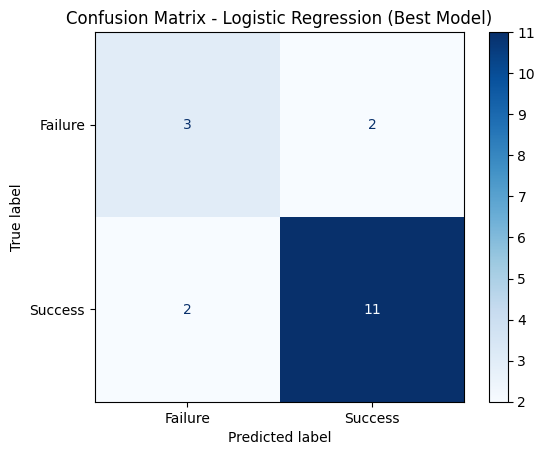


Classification Report:
              precision    recall  f1-score   support

     Failure       0.60      0.60      0.60         5
     Success       0.85      0.85      0.85        13

    accuracy                           0.78        18
   macro avg       0.72      0.72      0.72        18
weighted avg       0.78      0.78      0.78        18



In [36]:
# Calcola accuratezza sul test set
test_accuracy = logreg_cv.score(X_test, Y_test)
print(f"Accuracy on test data: {test_accuracy:.4f} ({test_accuracy*100:.2f}%)")

# Predizioni
yhat = logreg_cv.predict(X_test)

# Matrice di confusione
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(Y_test, yhat)
print(f"\nConfusion Matrix:")
print(f"               Predicted")
print(f"               Failure  Success")
print(f"  Actual Failure   {cm[0,0]}        {cm[0,1]}")
print(f"  Actual Success   {cm[1,0]}        {cm[1,1]}")

# Visualizzazione
ConfusionMatrixDisplay.from_predictions(Y_test, yhat, 
                                         display_labels=['Failure', 'Success'],
                                         cmap='Blues')
plt.title('Confusion Matrix - Logistic Regression (Best Model)')
plt.show()

# Metriche dettagliate
from sklearn.metrics import classification_report
print("\nClassification Report:")
print(classification_report(Y_test, yhat, target_names=['Failure', 'Success']))

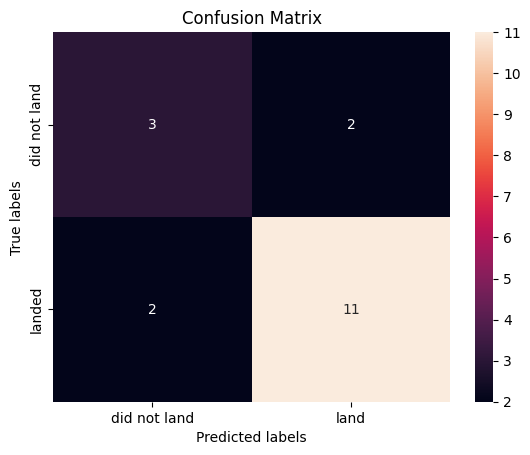

In [34]:
yhat=logreg_cv.predict(X_test)
plot_confusion_matrix(Y_test,yhat)

Examining the confusion matrix, we see that logistic regression can distinguish between the different classes.  We see that the problem is false positives.

Overview:

True Postive - 12 (True label is landed, Predicted label is also landed)

False Postive - 3 (True label is not landed, Predicted label is landed)


## TASK  6


Create a support vector machine object then  create a  <code>GridSearchCV</code> object  <code>svm_cv</code> with cv = 10.  Fit the object to find the best parameters from the dictionary <code>parameters</code>.


In [37]:
parameters = {'kernel':('linear', 'rbf','poly','rbf', 'sigmoid'),
              'C': np.logspace(-3, 3, 5),
              'gamma':np.logspace(-3, 3, 5)}
svm = SVC()

In [39]:
import pandas as pd
import numpy as np
from sklearn import preprocessing
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.svm import SVC

# Carica dati
df = pd.read_csv("dataset_part_2.csv")
Y = df['landing_class'].to_numpy()

feature_columns = ['FlightNumber', 'PayloadMass', 'Flights', 'GridFins', 
                   'Reused', 'Legs', 'Block', 'ReusedCount']
available_features = [col for col in feature_columns if col in df.columns]
X = df[available_features].copy()

# Standardizza
scaler = preprocessing.StandardScaler()
X_scaled = scaler.fit_transform(X)

# Split
X_train, X_test, Y_train, Y_test = train_test_split(X_scaled, Y, test_size=0.2, random_state=2)

# Parametri corretti
parameters = {
    'kernel': ['linear', 'rbf', 'poly', 'sigmoid'],
    'C': [0.01, 0.1, 1, 10, 100],
    'gamma': ['scale', 'auto', 0.001, 0.01, 0.1, 1]
}

# GridSearchCV
svm = SVC(random_state=42)
svm_cv = GridSearchCV(svm, parameters, cv=10, scoring='accuracy', verbose=1)
svm_cv.fit(X_train, Y_train)

Fitting 10 folds for each of 120 candidates, totalling 1200 fits


,estimator,SVC(random_state=42)
,param_grid,"{'C': [0.01, 0.1, ...], 'gamma': ['scale', 'auto', ...], 'kernel': ['linear', 'rbf', ...]}"
,scoring,'accuracy'
,n_jobs,None
,refit,True
,cv,10
,verbose,1
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,C,10


In [40]:
print("tuned hpyerparameters :(best parameters) ",svm_cv.best_params_)
print("accuracy :",svm_cv.best_score_)

tuned hpyerparameters :(best parameters)  {'C': 10, 'gamma': 1, 'kernel': 'rbf'}
accuracy : 0.8857142857142858


## TASK  7


Calculate the accuracy on the test data using the method <code>score</code>:


Accuracy on test data: 0.7777777777777778
Confusion Matrix:
[[ 2  3]
 [ 1 12]]


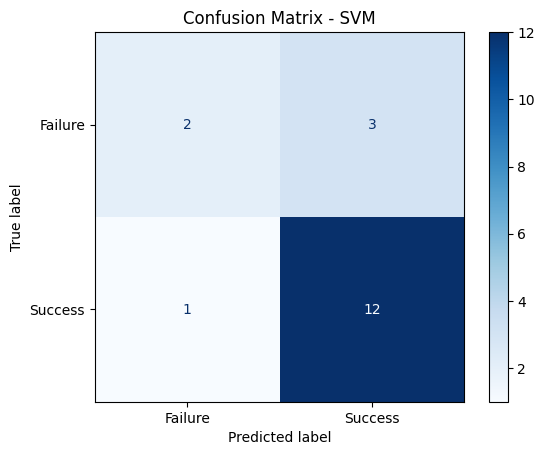

In [43]:
# Calcola accuratezza sul test set
test_accuracy = svm_cv.score(X_test, Y_test)
print("Accuracy on test data:", test_accuracy)

# Predizioni
yhat = svm_cv.predict(X_test)

# Matrice di confusione
cm = confusion_matrix(Y_test, yhat)
print("Confusion Matrix:")
print(cm)

# Visualizzazione
ConfusionMatrixDisplay.from_predictions(Y_test, yhat, 
                                         display_labels=['Failure', 'Success'],
                                         cmap='Blues')
plt.title('Confusion Matrix - SVM')
plt.show()

We can plot the confusion matrix


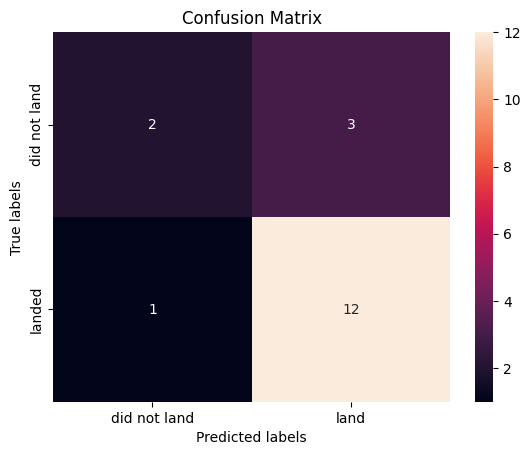

In [44]:
yhat=svm_cv.predict(X_test)
plot_confusion_matrix(Y_test,yhat)

## TASK  8


Create a decision tree classifier object then  create a  <code>GridSearchCV</code> object  <code>tree_cv</code> with cv = 10.  Fit the object to find the best parameters from the dictionary <code>parameters</code>.


In [41]:
import pandas as pd
import numpy as np
from sklearn import preprocessing
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.tree import DecisionTreeClassifier

# Carica dati
df = pd.read_csv("dataset_part_2.csv")
Y = df['landing_class'].to_numpy()

feature_columns = ['FlightNumber', 'PayloadMass', 'Flights', 'GridFins', 
                   'Reused', 'Legs', 'Block', 'ReusedCount']
available_features = [col for col in feature_columns if col in df.columns]
X = df[available_features].copy()

# Standardizza
scaler = preprocessing.StandardScaler()
X_scaled = scaler.fit_transform(X)

# Split
X_train, X_test, Y_train, Y_test = train_test_split(X_scaled, Y, test_size=0.2, random_state=2)

# Parametri
parameters = {
    'criterion': ['gini', 'entropy'],
    'splitter': ['best', 'random'],
    'max_depth': [2, 4, 6, 8, 10, 12, 14, 16, 18],
    'max_features': ['sqrt', 'log2'],
    'min_samples_leaf': [1, 2, 4],
    'min_samples_split': [2, 5, 10]
}

# GridSearchCV
tree = DecisionTreeClassifier(random_state=42)
tree_cv = GridSearchCV(tree, parameters, cv=10, scoring='accuracy', verbose=1)
tree_cv.fit(X_train, Y_train)

Fitting 10 folds for each of 648 candidates, totalling 6480 fits


,estimator,DecisionTreeC...ndom_state=42)
,param_grid,"{'criterion': ['gini', 'entropy'], 'max_depth': [2, 4, ...], 'max_features': ['sqrt', 'log2'], 'min_samples_leaf': [1, 2, ...], ...}"
,scoring,'accuracy'
,n_jobs,None
,refit,True
,cv,10
,verbose,1
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,criterion,'gini'


In [42]:
# Risultati
print("tuned hyperparameters : (best parameters) ", tree_cv.best_params_)
print("accuracy :", tree_cv.best_score_)

tuned hyperparameters : (best parameters)  {'criterion': 'gini', 'max_depth': 8, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'splitter': 'random'}
accuracy : 0.9446428571428571


## TASK  9


Calculate the accuracy of tree_cv on the test data using the method <code>score</code>:


Accuracy on test data: 0.8333333333333334
Confusion Matrix:
[[ 3  2]
 [ 1 12]]


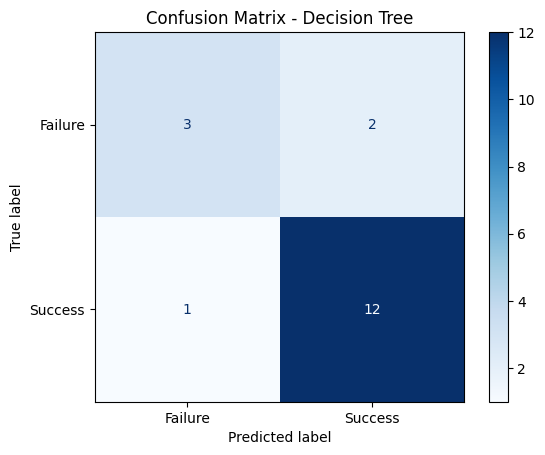

In [45]:
# Calcola accuratezza sul test set
test_accuracy = tree_cv.score(X_test, Y_test)
print("Accuracy on test data:", test_accuracy)

# Predizioni
yhat = tree_cv.predict(X_test)

# Matrice di confusione
cm = confusion_matrix(Y_test, yhat)
print("Confusion Matrix:")
print(cm)

# Visualizzazione
ConfusionMatrixDisplay.from_predictions(Y_test, yhat, 
                                         display_labels=['Failure', 'Success'],
                                         cmap='Blues')
plt.title('Confusion Matrix - Decision Tree')
plt.show()

We can plot the confusion matrix


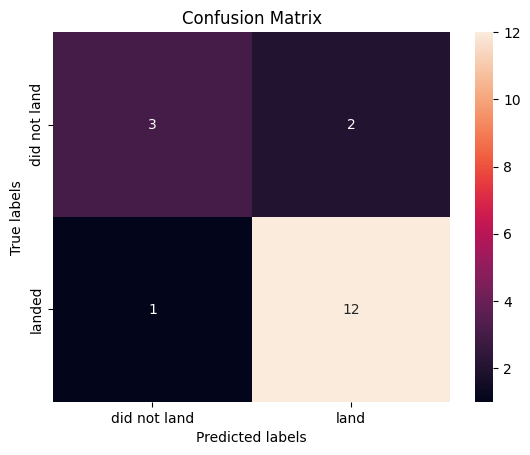

In [46]:
yhat = tree_cv.predict(X_test)
plot_confusion_matrix(Y_test,yhat)

## TASK  10


Create a k nearest neighbors object then  create a  <code>GridSearchCV</code> object  <code>knn_cv</code> with cv = 10.  Fit the object to find the best parameters from the dictionary <code>parameters</code>.


In [48]:
import pandas as pd
import numpy as np
from sklearn import preprocessing
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.neighbors import KNeighborsClassifier

# Carica dati
df = pd.read_csv("dataset_part_2.csv")
Y = df['landing_class'].to_numpy()

feature_columns = ['FlightNumber', 'PayloadMass', 'Flights', 'GridFins', 
                   'Reused', 'Legs', 'Block', 'ReusedCount']
available_features = [col for col in feature_columns if col in df.columns]
X = df[available_features].copy()

# Standardizza
scaler = preprocessing.StandardScaler()
X_scaled = scaler.fit_transform(X)

# Split
X_train, X_test, Y_train, Y_test = train_test_split(X_scaled, Y, test_size=0.2, random_state=2)

# Parametri
parameters = {
    'n_neighbors': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
    'algorithm': ['auto', 'ball_tree', 'kd_tree', 'brute'],
    'p': [1, 2]
}

# GridSearchCV
knn = KNeighborsClassifier()
knn_cv = GridSearchCV(knn, parameters, cv=10, scoring='accuracy', verbose=1)
knn_cv.fit(X_train, Y_train)

# Risultati
print("tuned hyperparameters : (best parameters) ", knn_cv.best_params_)
print("accuracy :", knn_cv.best_score_)

Fitting 10 folds for each of 80 candidates, totalling 800 fits
tuned hyperparameters : (best parameters)  {'algorithm': 'auto', 'n_neighbors': 3, 'p': 1}
accuracy : 0.9428571428571428


In [49]:
print("tuned hpyerparameters :(best parameters) ",knn_cv.best_params_)
print("accuracy :",knn_cv.best_score_)

tuned hpyerparameters :(best parameters)  {'algorithm': 'auto', 'n_neighbors': 3, 'p': 1}
accuracy : 0.9428571428571428


## TASK  11


Calculate the accuracy of knn_cv on the test data using the method <code>score</code>:


Accuracy on test data: 0.9444444444444444
Confusion Matrix:
[[ 5  0]
 [ 1 12]]


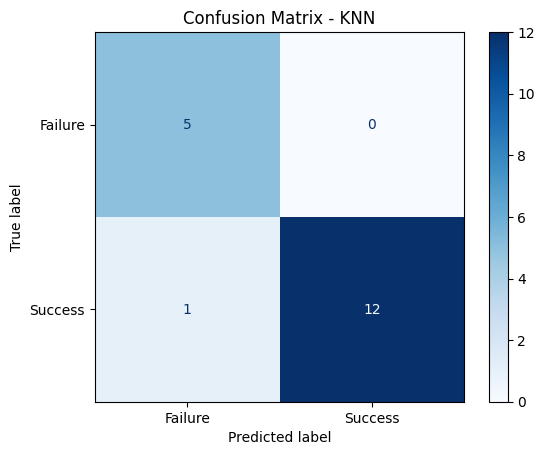

In [50]:
# Calcola accuratezza sul test set
test_accuracy = knn_cv.score(X_test, Y_test)
print("Accuracy on test data:", test_accuracy)

# Predizioni
yhat = knn_cv.predict(X_test)

# Matrice di confusione
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(Y_test, yhat)
print("Confusion Matrix:")
print(cm)

# Visualizzazione
ConfusionMatrixDisplay.from_predictions(Y_test, yhat, 
                                         display_labels=['Failure', 'Success'],
                                         cmap='Blues')
plt.title('Confusion Matrix - KNN')
plt.show()

We can plot the confusion matrix


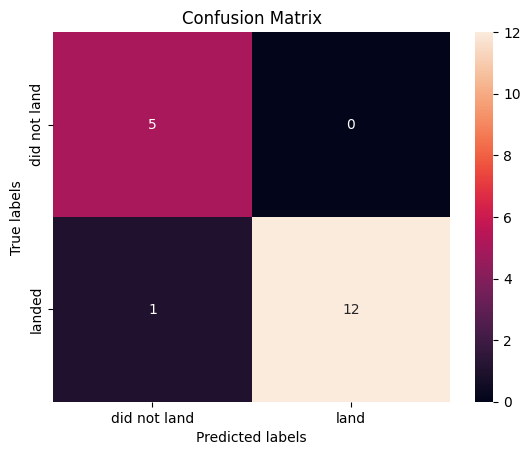

In [51]:
yhat = knn_cv.predict(X_test)
plot_confusion_matrix(Y_test,yhat)

## TASK  12


Find the method performs best:


In [52]:
print("="*60)
print("TASK 12: CONFRONTO DEI MODELLI")
print("="*60)

# Raccolta risultati
results = []

# Logistic Regression
try:
    logreg_acc = logreg_cv.best_score_
    logreg_test = logreg_cv.score(X_test, Y_test)
    results.append(('Logistic Regression', logreg_acc, logreg_test))
    print(f"\nLogistic Regression:")
    print(f"   Validation: {logreg_acc:.4f} ({logreg_acc*100:.2f}%)")
    print(f"   Test: {logreg_test:.4f} ({logreg_test*100:.2f}%)")
except NameError:
    print("\n⚠️ Logistic Regression non disponibile")

# SVM
try:
    svm_acc = svm_cv.best_score_
    svm_test = svm_cv.score(X_test, Y_test)
    results.append(('SVM', svm_acc, svm_test))
    print(f"\nSVM:")
    print(f"   Validation: {svm_acc:.4f} ({svm_acc*100:.2f}%)")
    print(f"   Test: {svm_test:.4f} ({svm_test*100:.2f}%)")
except NameError:
    print("\n⚠️ SVM non disponibile")

# Decision Tree
try:
    tree_acc = tree_cv.best_score_
    tree_test = tree_cv.score(X_test, Y_test)
    results.append(('Decision Tree', tree_acc, tree_test))
    print(f"\nDecision Tree:")
    print(f"   Validation: {tree_acc:.4f} ({tree_acc*100:.2f}%)")
    print(f"   Test: {tree_test:.4f} ({tree_test*100:.2f}%)")
except NameError:
    print("\n⚠️ Decision Tree non disponibile")

# KNN
try:
    knn_acc = knn_cv.best_score_
    knn_test = knn_cv.score(X_test, Y_test)
    results.append(('KNN', knn_acc, knn_test))
    print(f"\nKNN:")
    print(f"   Validation: {knn_acc:.4f} ({knn_acc*100:.2f}%)")
    print(f"   Test: {knn_test:.4f} ({knn_test*100:.2f}%)")
except NameError:
    print("\n⚠️ KNN non disponibile")

# Miglior modello
print("\n" + "="*60)
print("🏆 MIGLIOR MODELLO")
print("="*60)

if results:
    # Per validation
    best_val = max(results, key=lambda x: x[1])
    print(f"\nMigliore accuracy su validation:")
    print(f"   {best_val[0]}: {best_val[1]:.4f} ({best_val[1]*100:.2f}%)")
    
    # Per test
    best_test = max(results, key=lambda x: x[2])
    print(f"\nMigliore accuracy su test:")
    print(f"   {best_test[0]}: {best_test[2]:.4f} ({best_test[2]*100:.2f}%)")
    
    # Confronto finale
    if best_val[0] == best_test[0]:
        print(f"\n✅ {best_val[0]} è il miglior modello su entrambi i set!")
    else:
        print(f"\n⚠️ Il miglior modello su validation ({best_val[0]}) è diverso da quello su test ({best_test[0]})")
        print("   Considerare il trade-off tra bias e varianza")

print("\n" + "="*60)
print("✅ TASK 11 e 12 COMPLETATI!")
print("="*60)

TASK 12: CONFRONTO DEI MODELLI

Logistic Regression:
   Validation: 0.6643 (66.43%)
   Test: 0.7778 (77.78%)

SVM:
   Validation: 0.8857 (88.57%)
   Test: 0.7778 (77.78%)

Decision Tree:
   Validation: 0.9446 (94.46%)
   Test: 0.8333 (83.33%)

KNN:
   Validation: 0.9429 (94.29%)
   Test: 0.9444 (94.44%)

🏆 MIGLIOR MODELLO

Migliore accuracy su validation:
   Decision Tree: 0.9446 (94.46%)

Migliore accuracy su test:
   KNN: 0.9444 (94.44%)

⚠️ Il miglior modello su validation (Decision Tree) è diverso da quello su test (KNN)
   Considerare il trade-off tra bias e varianza

✅ TASK 11 e 12 COMPLETATI!


## Authors


In [53]:
# Numero di record nel test sample
print(f"Numero di record nel test sample: {len(Y_test)}")

Numero di record nel test sample: 18


[Pratiksha Verma](https://www.linkedin.com/in/pratiksha-verma-6487561b1/)


In [54]:
# Miglior kernel per SVM
print("Migliori parametri SVM:", svm_cv.best_params_)
print("Kernel migliore:", svm_cv.best_params_.get('kernel'))

Migliori parametri SVM: {'C': 10, 'gamma': 1, 'kernel': 'rbf'}
Kernel migliore: rbf


<!--## Change Log--!>


<!--| Date (YYYY-MM-DD) | Version | Changed By      | Change Description      |
| ----------------- | ------- | -------------   | ----------------------- |
| 2022-11-09        | 1.0     | Pratiksha Verma | Converted initial version to Jupyterlite|--!>


In [55]:
# Accuracy del Decision Tree sul test set
test_accuracy = tree_cv.score(X_test, Y_test)
print(f"Accuracy Decision Tree sul test set: {test_accuracy:.4f}")
print(f"Percentuale: {test_accuracy*100:.2f}%")

Accuracy Decision Tree sul test set: 0.8333
Percentuale: 83.33%


In [56]:
# Stampa il miglior kernel
best_kernel = svm_cv.best_params_.get('kernel')
print(f"Miglior kernel: {best_kernel}")

# Mostra tutti i kernel testati e le loro migliori accuracy
kernels = {}
for i, k in enumerate(svm_cv.cv_results_['param_kernel']):
    kernel = k
    acc = svm_cv.cv_results_['mean_test_score'][i]
    if kernel not in kernels or acc > kernels[kernel]:
        kernels[kernel] = acc

print("\nMiglior accuracy per ogni kernel:")
for k, acc in sorted(kernels.items(), key=lambda x: x[1], reverse=True):
    print(f"   {k}: {acc:.4f} ({acc*100:.2f}%)")

Miglior kernel: rbf

Miglior accuracy per ogni kernel:
   rbf: 0.8857 (88.57%)
   poly: 0.8464 (84.64%)
   sigmoid: 0.7339 (73.39%)
   linear: 0.6536 (65.36%)


### <h3 align="center"> IBM Corporation 2022. All rights reserved. <h3/>
